<a href="https://colab.research.google.com/github/joelalonsov/hyperblog/blob/main/Actividad2analisisPandas_A01796712.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC4029 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 2**
Pandas para el análisis de datos en Python

---

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


*   **NOMBRE**: Joel Alonso Vázquez
*   **MATRÍCULA**: A01796712


---

En esta actividad usarás el archivo de datos `LaqnData.csv`. Cada fila de este conjunto de datos muestra un registro de medición, por hora, de uno de los siguientes cinco contaminantes del aire:

*   `NO` (óxido nítrico)
*   `NO2` (dióxido de nitrógeno)
*   `NOX` (óxidos nitrosos)
*   `PM10` (partículas suspendidas con un diámetro aerodinámico igual o menor a 10 micrómetros)
*   `PM2.5` (partículas suspendidas con un diámetro aerodinámico igual o menor a 2.5 micrómetros)

Los datos se recopilaron en una ubicación de Londres durante todo el año 2017.

**NOTA IMPORTANTE:** Asegúrate de responder *explícitamente* todos los cuestionamientos.


1.	Descarga el archivo: `LaqnData.csv` y guarda, en un dataframe (`air_df`), todos sus registros.
*   Observa la estructura y contenido del dataframe con los atributos y métodos estudiados (`shape`, `columns`, `head()`, `tail()`, `dtypes`)
*   Calcula el porcentaje de valores faltantes por columna.

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive')

import pandas as pd

air_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/MNA/Ciencia y analitica de datos/LaqnData.csv')

print('\nUso de head: Muestra las primeras cinco filas del DataFrame.\n')
print(air_df.head())

print('\nUso de shape: Muestra la forma de DataFrame en número de filas y columnas.\n')
print(air_df.shape)

print('\nUso de columns: Muestra los nombres de las columnas del DataFrame.\n')
print(air_df.columns)

print('\nUso de tail: Muestra las ultimas cinco filas (por defecto) del DataFrame.\n')
print(air_df.tail())

print('\nUso de dtypes: Muestra los tipos de datos de cada columna del DataFrame.\n')
print(air_df.dtypes)

#Cálculo de valores faltantes por columna:

porcentaje_faltantes = air_df.isnull().sum() / len(air_df) * 100   #Total de valores nulos en cada columna entre el total de registros * 100
porcentaje_faltantes = porcentaje_faltantes.round(2)  # Redondeo a 2 decimales
print('\nPorcentaje de valores faltantes por columna:\n')
print(porcentaje_faltantes)



Uso de head: Muestra las primeras cinco filas del DataFrame.

  Site Species   ReadingDateTime  Value   Units Provisional or Ratified
0  CT3      NO  01/01/2017 00:00    3.5  ug m-3                       R
1  CT3      NO  01/01/2017 01:00    3.6  ug m-3                       R
2  CT3      NO  01/01/2017 02:00    2.2  ug m-3                       R
3  CT3      NO  01/01/2017 03:00    2.1  ug m-3                       R
4  CT3      NO  01/01/2017 04:00    3.3  ug m-3                       R

Uso de shape: Muestra la forma de DataFrame en número de filas y columnas.

(43800, 6)

Uso de columns: Muestra los nombres de las columnas del DataFrame.

Index(['Site', 'Species', 'ReadingDateTime', 'Value', 'Units',
       'Provisional or Ratified'],
      dtype='object')

Uso de tail: Muestra las ultimas cinco filas (por defecto) del DataFrame.

      Site Species   ReadingDateTime  Value   Units Provisional or Ratified
43795  CT3   PM2.5  31/12/2017 19:00   -2.0  ug m-3                       R


2.	Obtén la cantidad de valores únicos por columna (`nunique()`) para responder:


*   ¿Cuántas mediciones se hicieron?
*   ¿Cuántos contaminantes del aire (`Species`) se analizaron?
*   ¿Qué columnas no agregan ningún valor informativo porque el mismo valor en todo el conjunto de datos? Elimínalas del dataframe.
*   La columna `Units` tampoco posee valor informativo. Verifícalo con la función `unique()` y elimínala del dataframe.

Número de mediciones:

In [ ]:
print('Número de mediciones: {}'.format(len(air_df)))
print('Contaminantes analizados: {}\n'.format(air_df['Species'].nunique()))

print('Valores únicos en la columna Site: {} '.format(air_df['Site'].nunique()))
print('Valores únicos en la columna Species: {} '.format(air_df['Species'].nunique()))
print('Valores únicos en la columna ReadingDateTime: {} '.format(air_df['ReadingDateTime'].nunique()))
print('Valores únicos en la columna Value: {} '.format(air_df['Value'].nunique()))
print('Valores únicos en la columna Units: {} '.format(air_df['Units'].nunique()))
print('Valores únicos en la columna Provisional or Ratified: {} '.format(air_df['Provisional or Ratified'].nunique()))

print('\nValores de la columna Units: {}\n'.format(air_df['Units'].unique()))

print('Estos valores escritos de forma distinta parecen referirse a lo mismo, por eso se eliminará la columna \'Units\'')

#borrado de columnas innecesarias (con el mismo valor):
air_df.drop(columns=['Site','Units','Provisional or Ratified'], inplace=True)

print('\nComprobación de columnas después del borrado:')
air_df.head()

Número de mediciones: 43800
Contaminantes analizados: 5

Valores únicos en la columna Site: 1 
Valores únicos en la columna Species: 5 
Valores únicos en la columna ReadingDateTime: 8760 
Valores únicos en la columna Value: 1847 
Valores únicos en la columna Units: 3 
Valores únicos en la columna Provisional or Ratified: 1 

Valores de la columna Units: ['ug m-3' 'ug m-3 as NO2' 'ug/m3']

Estos valores escritos de forma distinta parecen referirse a lo mismo, por eso se eliminará la columna 'Units'

Comprobación de columnas después del borrado:


,Species,ReadingDateTime,Value
0,NO,01/01/2017 00:00,3.5
1,NO,01/01/2017 01:00,3.6
2,NO,01/01/2017 02:00,2.2
3,NO,01/01/2017 03:00,2.1
4,NO,01/01/2017 04:00,3.3


3.	Realiza el conteo de valores por categoría (`value_counts()`) para la columna `Species` y determina si las lecturas de cada contaminante coincide con el total de mediciones.

In [ ]:
print('\nConteo de valores de la columna \'Species\':')
print(air_df.Species.value_counts())

print('\nSuma de estos valores: {}'.format(air_df.Species.value_counts().sum()))

print('\nPor lo tanto, coincide con el total de mediciones.')



Conteo de valores de la columna 'Species':
Species
NO       8760
NO2      8760
NOX      8760
PM10     8760
PM2.5    8760
Name: count, dtype: int64

Suma de estos valores: 43800

Por lo tanto, coincide con el total de mediciones.


4.	Utiliza la función `groupby()` para determinar el promedio del valor por contaminante.

In [ ]:
print('\n Valor promedio por contaminante: \n')
air_df.groupby(['Species']).Value.mean()


 Valor promedio por contaminante: 



,Value
Species,
NO,15.045115
NO2,38.010185
NOX,61.078661
PM10,22.551704
PM2.5,14.999831


5.	El conjunto de datos está en un formato largo. Aplique la función apropiada para cambiarlo al formato ancho (`ReadingDateTime` como índice y cada contaminante en una columna). Nombre el dataframe resultante como `pvt_df`.

In [7]:
print('\nCambio a formato ancho:\n')
pvt_df = air_df.pivot(index='ReadingDateTime', columns='Species', values='Value')
pvt_df


Cambio a formato ancho:



Species,NO,NO2,NOX,PM10,PM2.5
ReadingDateTime,,,,,
01/01/2017 00:00,3.5,30.8,36.2,35.7,NaN
01/01/2017 01:00,3.6,31.5,37.0,28.5,NaN
01/01/2017 02:00,2.2,27.3,30.7,22.7,NaN
01/01/2017 03:00,2.1,23.5,26.8,20.5,NaN
01/01/2017 04:00,3.3,28.0,33.0,22.1,NaN
...,...,...,...,...,...
31/12/2017 19:00,0.7,17.5,18.5,16.3,-2.0
31/12/2017 20:00,0.7,17.5,18.6,14.5,6.0
31/12/2017 21:00,0.7,14.1,15.1,8.6,5.0


6.	A través de la función `describe()` responde:

*   ¿Cuál es el mayor valor de `NO2` registrado? ¿A qué día pertenece?
*   ¿Cuál es el menor valor de `PM10` registrado?¿A qué día pertenece?
*   ¿Cuál es la mediana del `NO`? ¿Cómo se interpreta?
*   ¿Cuál es el primer cuartil de `PM2.5`? ¿Qué significa?

In [12]:
print(pvt_df.describe())

valor_maximo_NO2 = pvt_df['NO2'].max()
print('\nEl valor máximo de NO2 registrado es: {}'.format(valor_maximo_NO2))
fecha_maximo_NO2 = pvt_df['NO2'].idxmax()
print('La fecha correspondiente al mayor valor registrado de NO2 es: {}'. format(fecha_maximo_NO2))

valor_minimo_PM10 = pvt_df['PM10'].min()
print('\nEl valor mínimo de PM10 registrado es: {}'.format(valor_minimo_PM10))
fecha_minimo_PM10 = pvt_df['PM10'].idxmin()
print('\nLa fecha correspondiente al menor valor registrado de M10 es: {}'.format(fecha_minimo_PM10))

mediana_de_NO = pvt_df['NO'].median()
print('\nLa mediana del NO es: {}'.format(mediana_de_NO))
print('El valor de la mediana es el valor central que ocupa cuando los datos están ordenados de menor a mayor.')

cuartil_25_PM2_5 = pvt_df['PM2.5'].quantile(0.25)
print('\nEl primer cuartil de PM2.5 es: {}'.format(cuartil_25_PM2_5))
print('El valor del primer cuartil significa que el 25% de los datos son menores o iguales al valor del primer cuartil, cuando están ordenados de menor a mayor.')


Species           NO          NO2          NOX         PM10        PM2.5
count    8660.000000  8660.000000  8660.000000  8657.000000  5933.000000
mean       15.045115    38.010185    61.078661    22.551704    14.999831
std        26.678565    18.580841    54.584805    15.344755    13.558588
min        -2.000000     2.800000     1.000000    -5.600000    -8.000000
25%         3.100000    23.800000    30.300000    13.900000     7.000000
50%         7.100000    35.300000    46.900000    19.500000    11.000000
75%        15.500000    49.900000    73.800000    27.300000    18.000000
max       401.799990   120.200000   734.299990   633.099980   128.000000

El valor máximo de NO2 registrado es: 120.2
La fecha correspondiente al mayor valor registrado de NO2 es: 24/01/2017 19:00

El valor mínimo de PM10 registrado es: -5.6

La fecha correspondiente al menor valor registrado de M10 es: 12/09/2017 23:00

La mediana del NO es: 7.1
El valor de la mediana es el valor central que ocupa cuando los dat

7.	Dibuja un histograma para cada columna de `pvt_df`. ¿Qué contaminante tiene mayor variabilidad?

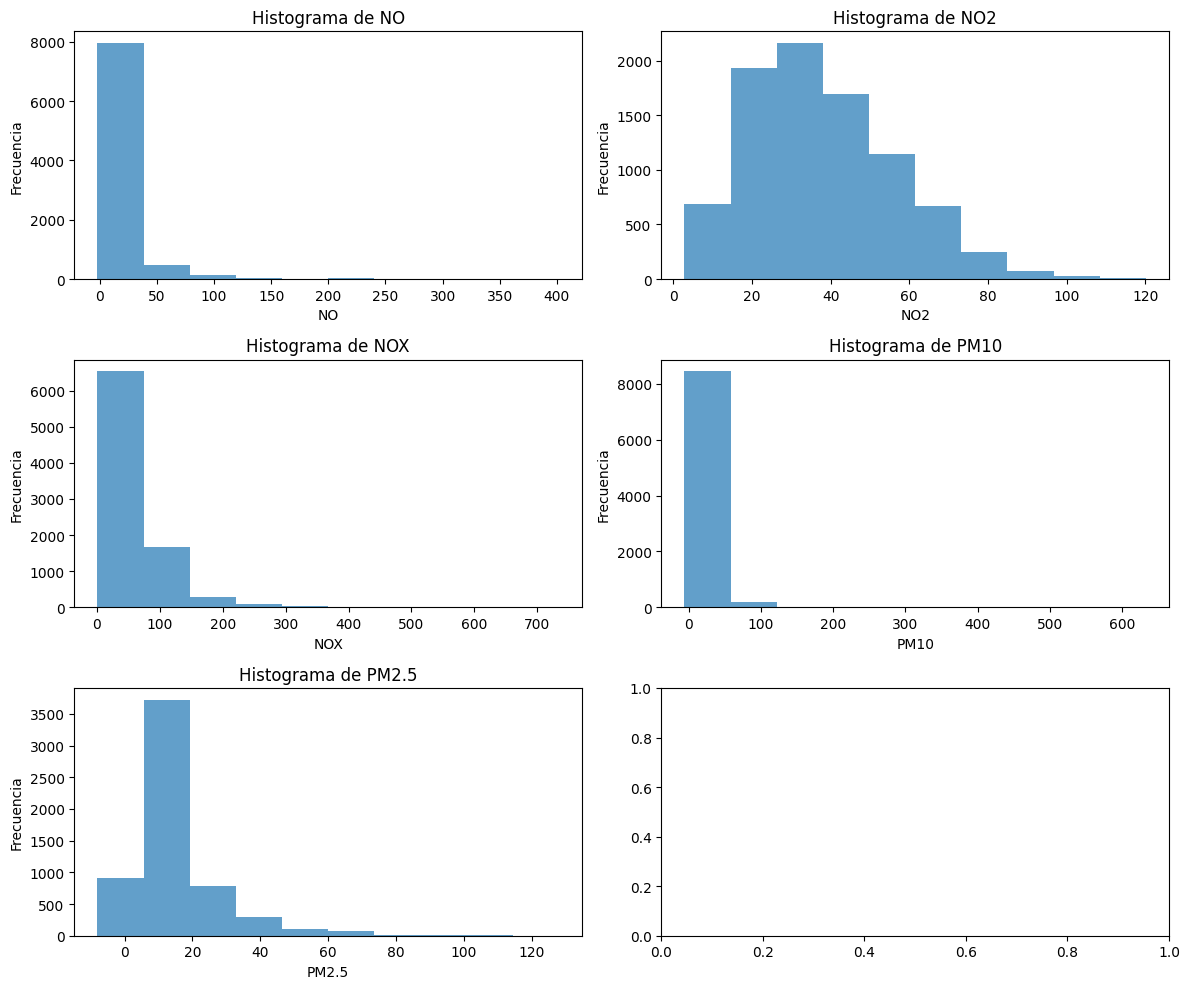


El contaminante con mayor variabilidad es el NO2, pues como se puede apreciar en su histograma los rangos varían desde casi cero hasta mas de 100 en frecuencias similares


In [29]:
#pvt_df.NO.plot.hist()
#pvt_df.NO2.plot.hist()
#pvt_df.NOX.plot.hist()
#pvt_df.PM10.plot.hist()
#pvt_df['PM2.5'].plot.hist()

import matplotlib.pyplot as plt

# Crear subplots para crear una figura con múltiples subgráficas (subplots) de forma organizada.
# así se pueden mostrar varios gráficos en una sola figura.

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 10))

# Lista de columnas y sus respectivos ejes
columns = ['NO', 'NO2', 'NOX', 'PM10', 'PM2.5']
axes = axes.flatten()  # Aplanar la matriz de ejes para convertir un
# arreglo multidimensional en una estructura unidimensional. Para crear
# múltiples subgráficas desde un solo arreglo unidimensional.

# Graficar cada histograma en un subplot
for i, column in enumerate(columns):
    pvt_df[column].plot.hist(ax=axes[i], bins=10, alpha=0.7)
    axes[i].set_title(f'Histograma de {column}')
    axes[i].set_xlabel(column)
    axes[i].set_ylabel('Frecuencia')

# Ajustar el diseño
plt.tight_layout()
plt.show()

#La función tight_layout() de matplotlib se utiliza para ajustar automáticamente
# los espacios entre los subgráficos de una figura para evitar que se superpongan
# y asegurar que todos los elementos se visualicen correctamente.

print('\nEl contaminante con mayor variabilidad es el NO2, pues como se puede apreciar en su histograma los rangos varían desde casi cero hasta mas de 100 en frecuencias similares.')

8.	Ejecuta el siguiente código y comenta qué hace cada línea:

In [30]:
# Toma la columna ReadingDateTime como fecha y la separa en fecha y hora.
# utiliza ' ' para identificar en donde se separa
datetime_df = air_df.ReadingDateTime.str.split(' ',expand=True) # Expand asigna el resultado como DataFrame, no como serie.

# Asigna los nombres para las nuevas columnas "Date" y "Time"
datetime_df.columns = ['Date','Time']

# Escribe
datetime_df
date_df = datetime_df.Date.str.split('/',expand=True) # Divide nuevamente la fecha en 'Day', 'Month' y 'Year' usando '/' como delimitador
date_df.columns = ['Day','Month','Year']
date_df

# Se une el DataFrame air_df con date_df, agregando las columnas "Day", "Month"y "Year"
air_df = air_df.join(date_df).join(datetime_df.Time).drop(columns=['ReadingDateTime','Year']) # Se eliminan la columnas "ReadingDateTime" y "Year"
air_df = air_df.set_index(['Month','Day','Time','Species']) # Se establecen nuevos índices para air_df
air_df # Se muestra el resultado de el nuevo DataFrame resultado de la unión

Site  Value   Units Provisional or Ratified
Month Day Time  Species                                            
01    01  00:00 NO       CT3    3.5  ug m-3                       R
          01:00 NO       CT3    3.6  ug m-3                       R
          02:00 NO       CT3    2.2  ug m-3                       R
          03:00 NO       CT3    2.1  ug m-3                       R
          04:00 NO       CT3    3.3  ug m-3                       R
...                      ...    ...     ...                     ...
12    31  19:00 PM2.5    CT3   -2.0  ug m-3                       R
          20:00 PM2.5    CT3    6.0  ug m-3                       R
          21:00 PM2.5    CT3    5.0  ug m-3                       R
          22:00 PM2.5    CT3    5.0  ug m-3                       R
          23:00 PM2.5    CT3    6.0  ug m-3                       R

[43800 rows x 4 columns]

9. Ejecuta la siguiente instrucción y compara su salida con la del código anterior (ejercicio 8). ¿Son iguales?

In [31]:
air_df.unstack()

Site                      Value                          \
Species           NO  NO2  NOX PM10 PM2.5    NO   NO2   NOX  PM10 PM2.5   
Month Day Time                                                            
01    01  00:00  CT3  CT3  CT3  CT3   CT3   3.5  30.8  36.2  35.7   NaN   
          01:00  CT3  CT3  CT3  CT3   CT3   3.6  31.5  37.0  28.5   NaN   
          02:00  CT3  CT3  CT3  CT3   CT3   2.2  27.3  30.7  22.7   NaN   
          03:00  CT3  CT3  CT3  CT3   CT3   2.1  23.5  26.8  20.5   NaN   
          04:00  CT3  CT3  CT3  CT3   CT3   3.3  28.0  33.0  22.1   NaN   
...              ...  ...  ...  ...   ...   ...   ...   ...   ...   ...   
12    31  19:00  CT3  CT3  CT3  CT3   CT3   0.7  17.5  18.5  16.3  -2.0   
          20:00  CT3  CT3  CT3  CT3   CT3   0.7  17.5  18.6  14.5   6.0   
          21:00  CT3  CT3  CT3  CT3   CT3   0.7  14.1  15.1   8.6   5.0   
          22:00  CT3  CT3  CT3  CT3   CT3   1.1  22.0  23.6  12.5   5.0   
          23:00  CT3  CT3  CT3  CT3   CT3   0.9  19.4  20.7  10.4   6.0   

                  Units                                        \
Species              NO     NO2            NOX   PM10   PM2.5   
Month Day Time                                                  
01    01  00:00  ug m-3  ug m-3  ug m-3 as NO2  ug/m3  ug m-3   
          01:00  ug m-3  ug m-3  ug m-3 as NO2  ug/m3  ug m-3   
          02:00  ug m-3  ug m-3  ug m-3 as NO2  ug/m3  ug m-3   
          03:00  ug m-3  ug m-3  ug m-3 as NO2  ug/m3  ug m-3   
          04:00  ug m-3  ug m-3  ug m-3 as NO2  ug/m3  ug m-3   
...                 ...     ...            ...    ...     ...   
12    31  19:00  ug m-3  ug m-3  ug m-3 as NO2  ug/m3  ug m-3   
          20:00  ug m-3  ug m-3  ug m-3 as NO2  ug/m3  ug m-3   
          21:00  ug m-3  ug m-3  ug m-3 as NO2  ug/m3  ug m-3   
          22:00  ug m-3  ug m-3  ug m-3 as NO2  ug/m3  ug m-3   
          23:00  ug m-3  ug m-3  ug m-3 as NO2  ug/m3  ug m-3   

                Provisional or Ratified                     
Species                              NO NO2 NOX PM10 PM2.5  
Month Day Time                                              
01    01  00:00                       R   R   R    R     R  
          01:00                       R   R   R    R     R  
          02:00                       R   R   R    R     R  
          03:00                       R   R   R    R     R  
          04:00                       R   R   R    R     R  
...                                 ...  ..  ..  ...   ...  
12    31  19:00                       R   R   R    R     R  
          20:00                       R   R   R    R     R  
          21:00                       R   R   R    R     R  
          22:00                       R   R   R    R     R  
          23:00                       R   R   R    R     R  

[8760 rows x 20 columns]


Las salidas son diferentes.

Como lo menciona Roy Jafari en su libro "Hands-On Data Preprocessing in Python: "La función inserta el nivel externo del índice multinivel en las columnas.

Transforma el DataFrame a un formato ancho mostrando los valores para cada columna "Site", "Value" y "Units", cada uno con los valores registrados en cada fecha y hora. Podría decirse que .unstack provee información más detallada de los registros.

10.	Explica cuáles son las diferencias y similitudes entre el par `melt()/pivot()` y el par `stack()/unstack()`. Si tuvieras que elegir una contraparte para `melt()` entre `stack()/unstack()`, ¿cuál elegirías? ¿Por qué?

**melt / pivot**

Permiten cambiar entre dos formatos de estructuras dimensionales, entre el formato ancho y largo.
melt cambia a formato largo y pivot cambia a formato ancho.

**stack / unstack**
Similar a las funciones anteriores, stack transforma las columnas en filas, y unstack (como des-apilar) convierte las filas en columnas para proporcionar más detalle.

En oposición a melt(), podría seleccionarse unstack para proporcionar una visión extendida de la información.


